## Installations and Imports

In [73]:
# In case you don't have qiskit, install it now
%pip install qiskit --quiet
%pip install qiskit-aer --quiet

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [74]:
# Installing/upgrading pylatexenc seems to have fixed my mpl issue
# If you try this and it doesn't work, try also restarting the runtime/kernel
%pip install pylatexenc --quiet
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [75]:
# Let's go ahead and import all this stuff too
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import Aer
from qiskit.quantum_info import Statevector, DensityMatrix, partial_trace
import numpy as np
from qiskit.visualization import plot_histogram, plot_state_qsphere, plot_bloch_multivector, plot_bloch_vector
import getpass
import random

# Card definition

In [76]:
class Card:
    def __init__(self, type, values = []):
        self.qc = QuantumCircuit(1)
        self.measure = False
        self.gate = False
        self.qi = False
        self.playable = True

        #with a single-computer system, nopes are hard to implement; may ignore for scope
        self.nope = False

        self.type = type
        match self.type:
            case "H":
                self.gate = True
                self.qc.h(0)
            case "X":
                self.gate = True
                self.qc.x(0)
            case "I":
                self.gate = True
                self.qc.id(0)
            case "Y":
                self.gate = True
                self.qc.y(0)
            case "Z":
                self.gate = True
                self.qc.z(0)
            case "S":
                self.gate = True
                self.qc.s(0)
            case "T":
                self.gate = True
                self.qc.t(0)
            case "Measure":
                self.gate = False
                self.measure = True
            case "Quantum Immortality":
                self.qi = True
                self.playable = False
            case "Nope":
                self.nope = True
        # otherwise is an action card
        #"None", "Dead", or "Alive"; if "Dead", out for the rest of the game
        self.measure_result = "None"

    def __str__(self):
        return f"type"

    def isGate(self):
        return self.gate

    def isMeasure(self):
        return self.measure

    def isQuantumImmortality(self):
        return self.qi

    def isAction(self):
        return not self.isGate() and not self.isMeasure() and not self.isQuantumImmortality() and not self.isNope()

    def isNope(self):
        return self.nope


    def measure(qc):
      qc_copy = qc.copy()
      qc_copy.measure()
      backend = Aer.get_backend("qasm_simulator")
      job = backend.run(qc_copy, shots=1, memory=True)
      result = job.result()
      memory = result.get_memory()
      return memory

    '''
    qc - the quantum register of the game state
    qubits - list of which qubit(s) to do action to
    choice - the action to take
    '''

    def apply_card(self, qc, indices, choice):
        if self.gate:
            qc.append(self.qc, indices)
        elif self.measure:
            return measure(qc)
    
    def get_label(self):
        return self.type


# Player Class Definition

In [77]:
class Player:
    def __init__(self, player_id, qc):
        self.hand = []
        self.hand.append(Card("Quantum Immortality"))
        self.alive = True
        self.player_id = player_id
        self.qc = qc #global qc of this game state
    
    def get_card_count(self):
        return len(self.hand)
    
    def get_card(self, i):
        return self.hand[i]
    
    def draw(self):
        state = Statevector.from_instruction(self.qc)
        dm = DensityMatrix(state)
        target = 1
        keep_dm = partial_trace(dm, [i for i in range(self.qc.num_qubits) if i != target])
        fig = plot_bloch_multivector(keep_dm)

        # img_path = "assets/bloch.png"
        # fig.savefig(img_path)
        # plt.close(fig)
        display(fig)

# GameState class definition

In [78]:
'''
Types of cards:

Single Gate cards => applies a gate to a player of your choosing, including yourself
H
X
I
Y
Z
S
T
U (TODO)

Double Gate card => apply a gate to two player's cards (TODO)
CNOT
SWAP

Measure cards => the "exploding kitten"; will measure the gate and determine results

Quantum Immortality cards => unplayable; will save one from a badly measured fate

Nope cards => special card that cancels a move, can be played anytime ()

Action cards => game actions one can take
Attack - force a player to take a turn 4
See the future - see the next three cards in the deck 5
Shuffle - shuffles the deck 4
Favor - steal a player's card of that player's choosing 4
Skip - end your turn without drawing 4

See another - see another person's qubit
Publish Paper - make one qubit public for that moment
'''

class GameState:
    card_labels = [
        "H",
        "X",
        "I",
        "Y",
        "Z",
        "S",
        "T",
        #"U",
        #"CNOT",
        "SWAP",
        "Measure",
        "Quantum Immortality",
        "Nope",
        "Attack",
        "See the future",
        "Shuffle",
        "Favor",
        "Skip",
        "See Another",
        "Publish Paper"

    ]
    '''
    Defines the game instance. The user interface should be able
    to query this function for all needs. Takes qc in and does
    game relevant manipulation.
    '''
    def __init__(self, num_players):
        #Init players
        self.players = []
        self.current_player = 0
        self.players_alive = num_players
        self.master_qc = QuantumCircuit(num_players, num_players)
        self.players_total = num_players
        for i in range(self.players_alive):
            self.master_qc.h(i)
        for i in range(self.players_alive):
            self.players.append(Player(i, self.master_qc))
        

        #Init deck w/out measures or quantum immortalities
        self.deck = []
        for i in range(self.players_alive):
            for label in GameState.card_labels:
                if label != "Measure" or label != "Quantum Immortality":
                    self.deck.append(Card(label))
        random.shuffle(self.deck)

        #Init player hands
        rng = np.random.default_rng()
        for i in range(self.players_alive):
            for j in range(6):
                r = rng.integers(0, len(self.deck))
                self.players[i].hand.append(self.deck.pop(i))
        random.shuffle(self.deck)
        
        #Add quantum immortalities and measures to deck
        for i in range(self.players_alive):
            for label in GameState.card_labels:
                self.deck.append(Card(label))
        random.shuffle(self.deck)
                
        #Init player qubits
        trueRand = False
        if trueRand:
            pass
        else:
            self.master_qc.h(self.master_qc.qubits)
            for i in range(self.players_alive):
                self.master_qc.p(rng.uniform(0, 2 * np.pi), i)
        
        
    
    def get_current_player(self):
        return self.players[self.current_player]


# Gameplay loop


In [79]:
class Game:
    def __init__(self, num_players):
        self.state = GameState(num_players)
    
    def take_turn(self):
        current_player_val = self.state.current_player
        print(f"Player {current_player_val}'s turn.")
        current_player = self.state.get_current_player()
        print("Your state:")
        current_player.draw()
        print("Your moves")
        for i in range(current_player.get_card_count()):
            print(f"{i}. {current_player.get_card(i).get_label()}")
        print(f"{current_player.get_card_count()}. Draw a card and end your turn")
        
        chosen_index = -1
        while (chosen_index==-1):
            try:
                move = int(input("Choose a move: "))
                if (move < 0 or move > current_player.get_card_count()):
                    print("Invalid input. Please enter a valid integer.")
                    continue
                elif (current_player.get_card(move).get_label() == "Nope"
                      or current_player.get_card(move).get_label() == "Quantum Immortality"):
                    print("You can't play that card!")
                    continue
                chosen_index = move
            except ValueError:
                print("Invalid input. Please enter a valid integer.")

        chosen_card = current_player.get_card(chosen_index)
        
        #Perform your move
        if chosen_card.isGate():
            #case; need to query who is getting this gate
            chosen_target = -1
            while (chosen_target==-1):
                try:
                    move = int(input("Choose a target player: "))
                    if (move < 0 or move > self.state):
                        print("Invalid input. Please enter a valid integer.")
                        continue
                    chosen_target = move
                except ValueError:
                    print("Invalid input. Please enter a valid integer.")
            chosen_card.apply_card(self.state.get_qc(), [chosen_target])
        
        

    '''
    Does the bruntwork of managing the gameplay loop:
    '''
    def gameplay_loop(self):
        # get the setup data
        while self.state.players_alive > 1:
            self.take_turn()
            break



Player 0's turn.
Your state:


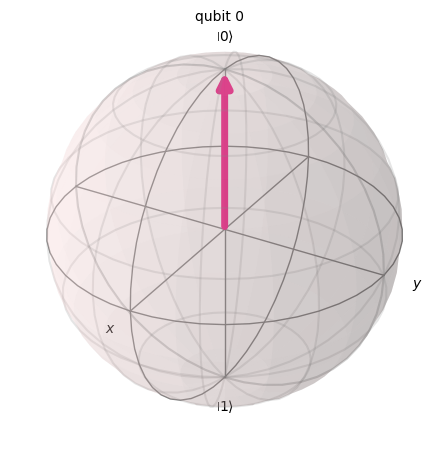

Your moves
0. Quantum Immortality
1. I
2. Quantum Immortality
3. See the future
4. Shuffle
5. Skip
6. See Another
7. Draw a card and end your turn


In [80]:
game = Game(2)
game.gameplay_loop()